In [1]:
#Assignment-1
#Name: Ashlesha Tayade             Name: Ruchika Gaikwad
#PRN: 260240128008                 PRN: 260240128036

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
RANDOM_STATE=24
np.random.RandomState(seed=RANDOM_STATE)

inpDir=Path('D:\\AshleshaRuchika\\PGCP-AI\\Deep Neural Networks\\dnndata')
outDir=Path('D:\\AshleshaRuchika\\PGCP-AI\\Deep Neural Networks\\dnndata\\output')
TEST_SIZE=0.2

In [4]:
data_df=pd.read_csv(inpDir/'breast_cancer_mod.csv')
data_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,1,0
1,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,1,0,1,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,1,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0


In [5]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,0.820738,0.383909,0.0,1.0,1.0,1.0,1.0
mean texture,569.0,0.880492,0.324671,0.0,1.0,1.0,1.0,1.0
mean perimeter,569.0,0.827768,0.377914,0.0,1.0,1.0,1.0,1.0
mean area,569.0,0.954306,0.209005,0.0,1.0,1.0,1.0,1.0
mean smoothness,569.0,0.811951,0.391095,0.0,1.0,1.0,1.0,1.0
mean compactness,569.0,0.910369,0.285904,0.0,1.0,1.0,1.0,1.0
mean concavity,569.0,0.917399,0.275520,0.0,1.0,1.0,1.0,1.0
mean concave points,569.0,0.899824,0.300498,0.0,1.0,1.0,1.0,1.0
mean symmetry,569.0,0.831283,0.374831,0.0,1.0,1.0,1.0,1.0
mean fractal dimension,569.0,0.927944,0.258809,0.0,1.0,1.0,1.0,1.0


In [6]:
data_df.isnull().sum().sum()

np.int64(0)

In [7]:
data_df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

[Text(1, 0, 'Maligant'), Text(0, 0, 'Benign')]

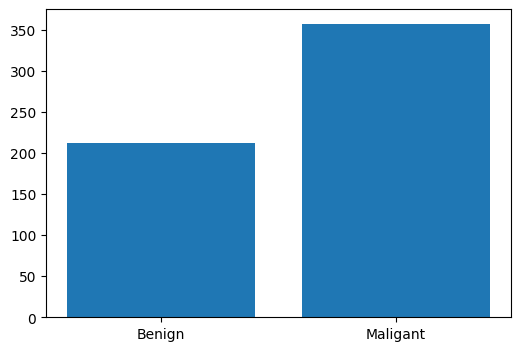

In [8]:
class_names=['Maligant','Benign']
fig,ax=plt.subplots(figsize=(6,4))
ax.bar(data_df['target'].value_counts().index,
      data_df['target'].value_counts().values)
ax.set_xticks(data_df['target'].value_counts().index)
ax.set_xticklabels(class_names)

In [9]:
features=data_df.drop('target',axis=1)
labels=data_df['target']
features.shape, labels.shape

((569, 30), (569,))

In [10]:
X_train,X_test,y_train,y_test=train_test_split(features,labels,test_size=TEST_SIZE,stratify=labels,random_state=RANDOM_STATE)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [11]:
assert(X_train.isin([0,1]).all().all()), 'Features must be binary'

In [12]:
X_train['total']=X_train.astype(np.int16).sum(axis=1)
X_train['target']=y_train
X_train.sort_values('total',inplace=True)
X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,total,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,1,1,12,0
2,0,1,0,0,0,0,0,0,0,1,...,0,1,0,1,1,0,1,1,13,0
1,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,13,0
8,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,1,1,15,0
7,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,15,0


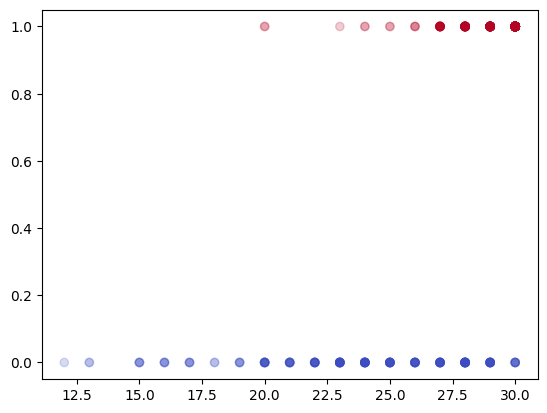

In [13]:
plt.scatter(X_train['total'],X_train['target'],c=X_train['target'],cmap='coolwarm',alpha=0.2)

In [14]:
accuracy={}
for b in range(X_train.shape[1]):
    X_train['pred']=X_train['total']>=b
    accuracy[b]=accuracy_score(X_train['pred'],X_train['target'])
print(accuracy)

{0: 0.6263736263736264, 1: 0.6263736263736264, 2: 0.6263736263736264, 3: 0.6263736263736264, 4: 0.6263736263736264, 5: 0.6263736263736264, 6: 0.6263736263736264, 7: 0.6263736263736264, 8: 0.6263736263736264, 9: 0.6263736263736264, 10: 0.6263736263736264, 11: 0.6263736263736264, 12: 0.6263736263736264, 13: 0.6285714285714286, 14: 0.6329670329670329, 15: 0.6329670329670329, 16: 0.6417582417582418, 17: 0.6505494505494506, 18: 0.6593406593406593, 19: 0.6637362637362637, 20: 0.6725274725274726, 21: 0.6901098901098901, 22: 0.7098901098901099, 23: 0.734065934065934, 24: 0.7692307692307693, 25: 0.8021978021978022, 26: 0.8307692307692308, 27: 0.8505494505494505, 28: 0.8483516483516483, 29: 0.8241758241758241, 30: 0.7472527472527473, 31: 0.37362637362637363}


In [15]:
best_b=max(accuracy,key=accuracy.get)
best_b

27

In [16]:
X_test['total']=X_test.astype(np.int16).sum(axis=1)# creating 'total' column
X_test['target']=y_test # adding back the labels

In [17]:
X_test['pred']= X_test['total']>=best_b # making predictions using best b
accuracy_score(X_test['pred'],X_test['target'])

0.868421052631579